<a href="https://colab.research.google.com/github/Jisura/genesys-adversary-generator/blob/master/regression_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Основы машинного обучения: лабораторная работа №2
## <!--Задание 1. -->Регрессионный анализ

В этом задании необходимо реализовать обучающиеся модели в контексте решения задачи регрессии на одном из представленных по варианту задания наборе данных.

### Цель

Получение навыков решения задачи регрессионного анализа и оптимизации функций методом градиентного спуска

### Оценивание и баллы

За это задание в общей сложности можно получить до 8 баллов. Задание частично проверяется автоматически, а частично будет оцениваться вручную. Чтобы получить максимальный балл,  необходимо успешно выполнить все приведенные ниже задачи.


***
#### Задачи

#### 1. Определить номер варианта
Перейдите по ссылке из личного кабинета на Google Таблицу со списком студентов. Найдите свое ФИО в списке и запомните соответствующий порядковый номер (поле № п/п) в первом столбце. Заполните его в ячейке ниже и выполните ячейку. Если вы не можете найти себя в списке, обратитесь к своему преподавателю.

In [2]:
### BEGIN YOUR CODE

Student_ID = 23

### END YOUR CODE

Теперь выполните следующую ячейку. Она вычислит номер задания и выведет его.

In [3]:
datasets = [('Combined Cycle Power Plant','https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant'), ('Beijing PM2.5','https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data'), ('Airfoil Self-Noise','https://archive.ics.uci.edu/dataset/291/airfoil+self+noise'), ('Energy Efficiency','https://archive.ics.uci.edu/dataset/242/energy+efficiency'), ('Bike Sharing','https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset'), ('Diabetes dataset','https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html#sklearn.datasets.load_diabetes'), ('California Housing','https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#fetch-california-housing'), ('Auto MPG', 'https://archive.ics.uci.edu/dataset/9/auto+mpg'), ('Forest Fires', 'https://archive.ics.uci.edu/dataset/162/forest+fires'), ('Concrete Compressive Strength', 'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength')]

dataset_id = None if Student_ID is None else Student_ID % len(datasets)
if dataset_id is None:
    print("ОШИБКА! Не указан порядковый номер студента в списке группы.")
else:
    print(f"Информация о датасете '{datasets[dataset_id][0]}' доступна по следующей ссылке: {datasets[dataset_id][1]}")

Информация о датасете 'Energy Efficiency' доступна по следующей ссылке: https://archive.ics.uci.edu/dataset/242/energy+efficiency


#### 2. Подготовить среду разработки и данные
Добавьте импорт всех необходимых библиотек в ячейке ниже. Постарайтесь не импортировать библиотеки в других ячейках, чтобы избежать ошибок в коде

In [4]:
### BEGIN YOUR CODE

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, HTML

### END YOUR CODE

При необходимости скачайте датасет с помощью команды `!wget ...` и разархивируйте его. Загрузите датасет в переменную `dataset`, с которой будете дальше работать

In [5]:
### BEGIN YOUR CODE

!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx

dataset = pd.read_excel("ENB2012_data.xlsx")

### END YOUR CODE

--2025-09-01 07:35:21--  https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘ENB2012_data.xlsx’

ENB2012_data.xlsx       [ <=>                ]  74.40K  --.-KB/s    in 0.1s    

2025-09-01 07:35:21 (541 KB/s) - ‘ENB2012_data.xlsx’ saved [76189]



####  3. Посмотреть на общую картину (0.5 балла)
Ознакомьтесь с информацией о датасете по ссылке из задания и **напишите один абзац текста с описанием решаемой задачи**. В частности, ответьте в своем тексте на следующие вопросы:

 * Каков размер датасета? (в Мб)
 * Сколько в нем записей (объектов)?
 * Сколько признаков (фич) у объектов в датасете?
 * Есть ли категориальные данные? Какие?
 * Есть ли пропущенные значения?
 * Есть ли в датасете столбец с ответами (target)? Какой у него тип данных?
 * Какую задачу может решать регрессионная модель, построенная на этом датасете? Какую величину она будет предсказывать?
 * Приведите основные статистические данные о датасете, которые можно получить вызовом одной-двух функций в pandas. Какие выводы о датасете можно сделать?

В ячейке ниже напишите код, который выводит всю необходимую информацию, а в ячейке под ней (ее тип - Markdown, т.е. текст) опишите своими словами решаемую задачу и используемый набор данных.

🔹 Размер файла: 0.07 Мб
🔹 Количество записей (объектов): 768
🔹 Количество признаков: 8


🔹 Категориальные признаки: Отсутствуют.
🔹 Пропущенные значения: Отсутствуют.

🔹 Целевые переменные (Target):
  - 'Нагрузка на отопление' (Y1), тип данных: float64
  - 'Нагрузка на охлаждение' (Y2), тип данных: float64

🎯 ПОСТАНОВКА ЗАДАЧИ
🔹 Тип задачи: Регрессия (предсказание непрерывного значения).
🔹 Цель: Построить модель, которая на основе архитектурных характеристик здания (X1-X8) сможет точно предсказывать его энергетические потребности: 'Нагрузку на отопление' (Y1) и 'Нагрузку на охлаждение' (Y2).


,Относительная компактность,Площадь поверхности,Площадь стен,Площадь крыши,Общая высота,Ориентация,Площадь остекления,Распределение остекления,Нагрузка на отопление,Нагрузка на охлаждение
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,0.76,671.71,318.50,176.60,5.25,3.50,0.23,2.81,22.31,24.59
std,0.11,88.09,43.63,45.17,1.75,1.12,0.13,1.55,10.09,9.51
min,0.62,514.50,245.00,110.25,3.50,2.00,0.00,0.00,6.01,10.90
25%,0.68,606.38,294.00,140.88,3.50,2.75,0.10,1.75,12.99,15.62
50%,0.75,673.75,318.50,183.75,5.25,3.50,0.25,3.00,18.95,22.08
75%,0.83,741.12,343.00,220.50,7.00,4.25,0.40,4.00,31.67,33.13
max,0.98,808.50,416.50,220.50,7.00,5.00,0.40,5.00,43.10,48.03


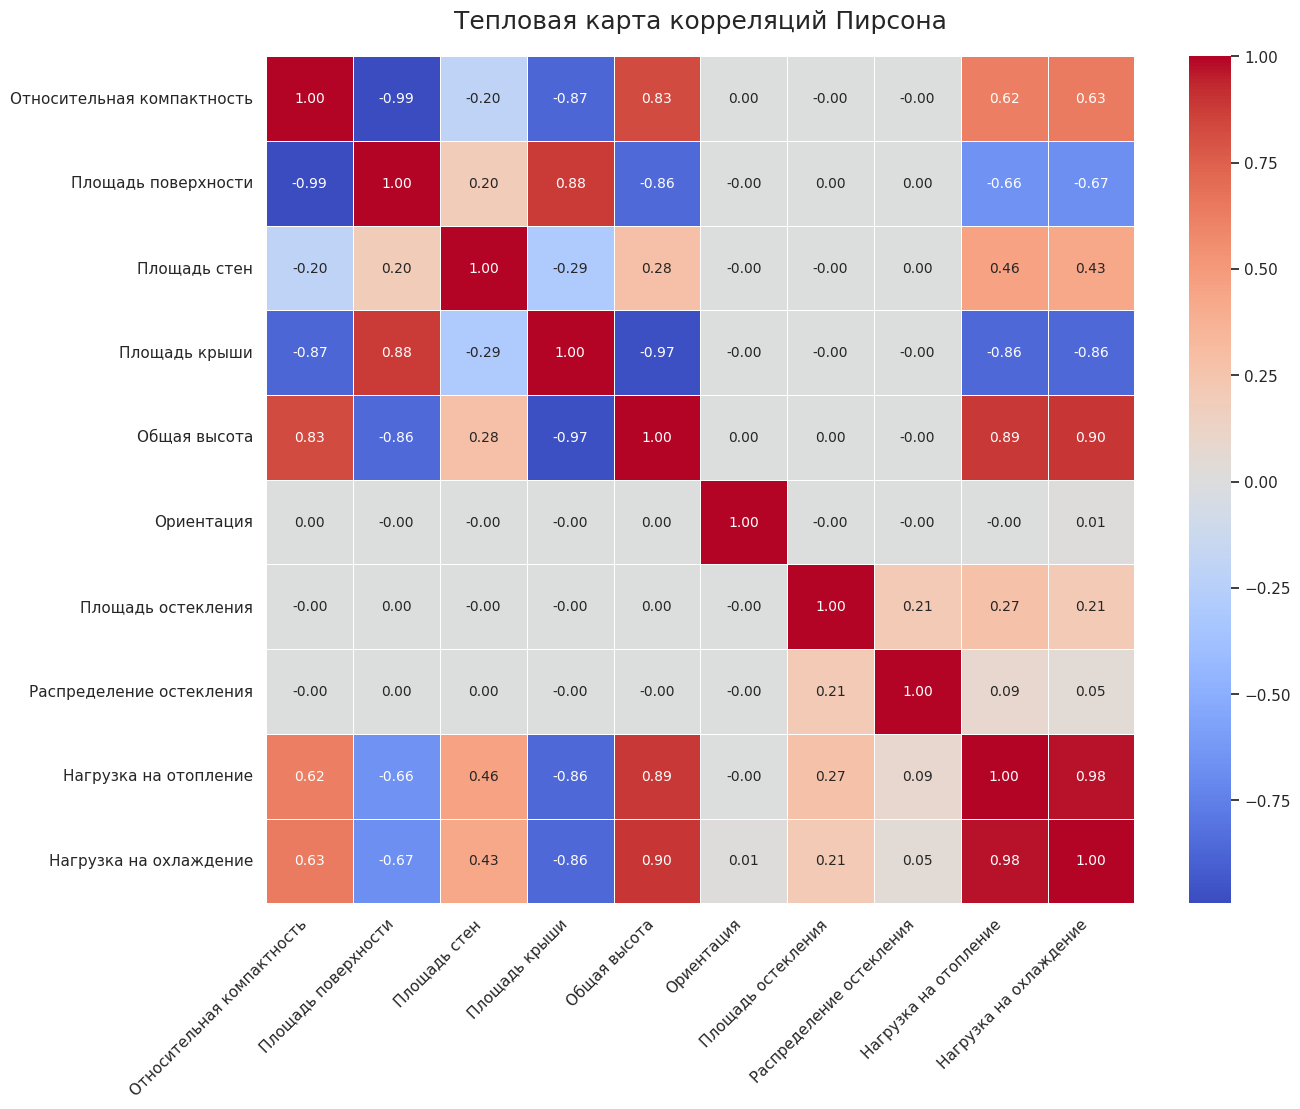

In [6]:
### BEGIN YOUR CODE

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

column_names_ru = {
    'X1': 'Относительная компактность',
    'X2': 'Площадь поверхности',
    'X3': 'Площадь стен',
    'X4': 'Площадь крыши',
    'X5': 'Общая высота',
    'X6': 'Ориентация',
    'X7': 'Площадь остекления',
    'X8': 'Распределение остекления',
    'Y1': 'Нагрузка на отопление',
    'Y2': 'Нагрузка на охлаждение'
}

dataset_ru = dataset.rename(columns=column_names_ru)

display(HTML("<h1>Аналитический отчет по датасету 'Energy Efficiency'</h1>"))
display(HTML("<h2>1. Общая информация о датасете</h2>"))

fz = os.path.getsize("ENB2012_data.xlsx")
fz_mb = fz / (1024 * 1024)
num_records = len(dataset_ru)
num_features = dataset_ru.shape[1] - 2

print(f"🔹 Размер файла: {fz_mb:.2f} Мб")
print(f"🔹 Количество записей (объектов): {num_records}")
print(f"🔹 Количество признаков: {num_features}")

display(HTML("<h2>2. Анализ структуры данных и постановка задачи</h2>"))

categorical_columns = dataset_ru.select_dtypes(include=['object']).columns
if len(categorical_columns) == 0:
    print("🔹 Категориальные признаки: Отсутствуют.")
else:
    print(f"🔹 Категориальные признаки: {list(categorical_columns)}")

if dataset_ru.isnull().sum().sum() == 0:
    print("🔹 Пропущенные значения: Отсутствуют.")
else:
    print("🔹 Пропущенные значения по столбцам:")
    display(dataset_ru.isnull().sum().to_frame(name='Количество пропусков'))

# Информация о целевых переменных
print("\n🔹 Целевые переменные (Target):")
print(f"  - 'Нагрузка на отопление' (Y1), тип данных: {dataset_ru['Нагрузка на отопление'].dtype}")
print(f"  - 'Нагрузка на охлаждение' (Y2), тип данных: {dataset_ru['Нагрузка на охлаждение'].dtype}")

print("\n" + "="*50)
print("🎯 ПОСТАНОВКА ЗАДАЧИ")
print("="*50)
print("🔹 Тип задачи: Регрессия (предсказание непрерывного значения).")
print("🔹 Цель: Построить модель, которая на основе архитектурных характеристик здания (X1-X8) сможет точно предсказывать его энергетические потребности: 'Нагрузку на отопление' (Y1) и 'Нагрузку на охлаждение' (Y2).")


display(HTML("<h2>3. Описательная статистика</h2>"))
styled_describe = dataset_ru.describe().style.background_gradient(cmap='viridis', axis=0)\
    .set_caption("Основные статистические показатели")\
    .format("{:.2f}")

display(styled_describe)

display(HTML("<h2>4. Корреляционный анализ (визуализация)</h2>"))
correlation_matrix = dataset_ru.corr()

plt.figure(figsize=(14, 11))
heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    annot_kws={"size": 10}
)

plt.title('Тепловая карта корреляций Пирсона', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

### END YOUR CODE

Размер датасета составляет **0.07 мегабайт**. В датасете содержится **768 записей**, описывающих различные характеристики зданий. Каждый объект представлен **8 признаками** (X1-X8), которые описывают параметры зданий, влияющие на энергоэффективность. **Категориальные признаки отсутствуют**. В датасете **нет пропущенных значений**, что упрощает задачу.

Столбцами с целевыми переменными являются **'Y1' (Heating Load - тепловая нагрузка) и 'Y2' (Cooling Load - нагрузка на охлаждение)**, оба имеют тип данных **float64**. Решаемая задача заключается в предсказании непрерывных значений тепловой/холодильной нагрузки здания. Ввиду высокой положительной корреляции меж значениями, мы будем делать предсказания только по тепловой нагрузке.


---


Анализ статистических данных показывает, что у признаков очень разный масштаб. Например, "Площадь поверхности" измеряется сотнями (от 514 до 808), а "Относительная компактность" — долями единицы (от 0.62 до 0.98). Такой разброс может ввести модель в заблуждение, заставив ее считать большие по значению признаки более важными. Поэтому перед обучением данные нужно обязательно масштабировать.

Также видно, что для целевых переменных (нагрузки на отопление и охлаждение) среднее значение выше медианы (значение 50%). Это говорит о том, что в данных есть небольшое количество зданий с аномально высокими нагрузками, которые смещают среднее.

Признаки "Ориентация" и "Распределение остекления" принимают всего несколько целых значений, что делает их похожими на категориальные, а не на непрерывные переменные.

В целом, данные выглядят качественными: во всех столбцах одинаковое количество записей (768), что означает отсутствие пропусков, а минимальные и максимальные значения выглядят логичными.


---


Анализ статистических данных показывает, что у признаков очень разный масштаб. Например, "Площадь поверхности" измеряется сотнями (от 514 до 808), а "Относительная компактность" — долями единицы (от 0.62 до 0.98). Такой разброс может ввести модель в заблуждение, заставив ее считать большие по значению признаки более важными. Поэтому перед обучением данные нужно обязательно масштабировать.

Также видно, что для целевых переменных (нагрузки на отопление и охлаждение) среднее значение выше медианы (значение 50%). Это говорит о том, что в данных есть небольшое количество зданий с аномально высокими нагрузками, которые смещают среднее.

Признаки "Ориентация" и "Распределение остекления" принимают всего несколько целых значений, что делает их похожими на категориальные, а не на непрерывные переменные.

В целом, данные выглядят качественными: во всех столбцах одинаковое количество записей (768), что означает отсутствие пропусков, а минимальные и максимальные значения выглядят логичными.
Анализ корреляционной матрицы показывает несколько ключевых проблем в данных.
Во-первых, целевые переменные Y1 (Нагрузка на отопление) и Y2 (Нагрузка на охлаждение) имеют корреляцию 0.98. Это означает, что они практически идентичны. Нет смысла строить модель для предсказания обеих. Нужно выбрать одну цель, например Y1, и работать только с ней.

Во-вторых, среди признаков есть сильная мультиколлинеарность. Признак X1 (Относительная компактность) и X2 (Площадь поверхности) имеют корреляцию -0.99. Это значит, что они несут одну и ту же информацию. То же самое касается пары X5 (Общая высота) и X4 (Площадь крыши) с их корреляцией -0.97.

В-третьих, признак X6 (Ориентация) имеет нулевую корреляцию со всеми остальными переменными, включая целевые.

Таким образом, план действий должен быть следующим. Сначала нужно определиться с единственной целевой переменной, Y1. Затем из набора данных необходимо удалить лишние признаки: X2 (дубликат X1), X4 (дубликат X5) и X6 (бесполезный). После этой очистки можно приступать к обучению модели на оставшихся признаках (X1, X3, X5, X7, X8). Это сделает модель более простой, стабильной и точной.

---
#### 4. Анализ данных, очистка, и масштабирование (2 балла)

**Анализ данных:** проверьте наличие корреляции между признаками, постройте корреляционную матрицу. Некоторые из признаков могут оказаться более коррелированными с объясняемой переменной (target), чем остальные. Эта информация в дальнейшем поможет провалидировать найденные коэффициенты регрессионной модели.

**Очистка данных:** если датасет содержит пропущенные значения, заполните их с помощью модуля [`sklearn.impute`](https://scikit-learn.org/stable/modules/impute.html). Если в датасете есть категориальные признаки, [преобразуйте их в числовые](https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-categorical-features) с помощью `OneHotEncoder`.

**Масштабирование признаков.** Напишите код, осуществляющий нормализацию значений всех признаков [следующим образом](https://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling):

- вычесть среднее значение соответствующего признака из всех значений этого признака;
- отмасштабировать (поделить) значения признаков на СКО этих признаков.

**Особенности реализации:** напишите код, который реализует последовательность (пайплайн) обработки обучающих данных, а затем примените его к валидационной и тестовой выборкам в случае их наличия.

In [9]:
### BEGIN YOUR CODE

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 1. Анализ данных и Очистка (Отбор признаков) ---
# На основе нашего предыдущего анализа корреляции, мы пришли к выводу,
# что некоторые признаки избыточны (мультиколлинеарность) или бесполезны.
# Их удаление — это важнейший шаг очистки данных для этого датасета.

print("Шаг 1: Анализ и отбор признаков")
# Определяем целевую переменную и исходные признаки
target_column = 'Y1'
initial_features = [col for col in dataset.columns if col.startswith('X')]

# Определяем признаки для удаления
features_to_drop = ['X2', 'X4', 'X6'] # X2 дублирует X1, X4 дублирует X5, X6 бесполезен

# Создаем финальный список признаков для модели
final_features = [feat for feat in initial_features if feat not in features_to_drop]

print(f"Исходные признаки: {initial_features}")
print(f"Признаки для удаления: {features_to_drop}")
print(f"Финальные признаки для модели: {final_features}\n")

# Создаем финальные X и y
X = dataset[final_features]
y = dataset[target_column]

# Проверка на пропуски (в этом датасете их нет, но это стандартная процедура)
print(f"Пропущенные значения в финальных признаках:\n{X.isnull().sum().to_string()}\n")


# --- 2. Разделение данных на обучающую, валидационную и тестовую выборки ---
# Сначала делим на обучающую (60%) и временную (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
# Затем делим временную пополам на валидационную (20%) и тестовую (20%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Шаг 2: Разделение данных")
print(f"Размер обучающей выборки (X_train): {X_train.shape}")
print(f"Размер валидационной выборки (X_val): {X_val.shape}")
print(f"Размер тестовой выборки (X_test): {X_test.shape}\n")


# --- 3. Создание универсального пайплайна для предобработки ---
# Этот пайплайн будет обрабатывать числовые и категориальные признаки по-разному.
# Он является универсальным шаблоном, даже если в текущих данных нет категорий или пропусков.

print("Шаг 3: Создание пайплайна предобработки")

# Определяем числовые и категориальные признаки (программно)
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Обнаруженные числовые признаки: {numeric_features}")
print(f"Обнаруженные категориальные признаки: {categorical_features}\n")

# Создаем пайплайн для обработки числовых признаков:
# 1. SimpleImputer заполняет пропущенные значения средним значением столбца.
# 2. StandardScaler выполняет нормализацию (вычитает среднее и делит на СКО).
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Создаем пайплайн для обработки категориальных признаков (на случай, если они появятся):
# 1. SimpleImputer заполняет пропуски самым частым значением.
# 2. OneHotEncoder преобразует категории в числовой формат.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Собираем все в один препроцессор с помощью ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Оставляем столбцы, которые не были указаны (если есть)
)


# --- 4. Применение пайплайна ---
print("Шаг 4: Обучение и применение пайплайна")

# Обучаем пайплайн ТОЛЬКО на обучающих данных (X_train)
# Это золотое правило: вся информация (средние, СКО и т.д.) для обработки
# должна извлекаться только из обучающей выборки, чтобы избежать утечки данных.
preprocessor.fit(X_train)

# Применяем обученный пайплайн ко всем выборкам
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Размер обработанной обучающей выборки: {X_train_processed.shape}")
print(f"Размер обработанной валидационной выборки: {X_val_processed.shape}")
print(f"Размер обработанной тестовой выборки: {X_test_processed.shape}\n")


# --- 5. Проверка результатов (опционально) ---
# Преобразуем обработанные данные обратно в DataFrame для наглядности
X_train_processed_df = pd.DataFrame(X_train_processed, columns=final_features, index=X_train.index)

print("Шаг 5: Проверка результатов масштабирования")
print("Первые 5 строк обработанных обучающих данных:")
print(X_train_processed_df.head())
print("\n")

# Проверим, что среднее близко к 0 и СКО близко к 1 для X_train_processed_df
print("Статистика для обработанных обучающих данных (проверка нормализации):")
print(X_train_processed_df.describe().loc[['mean', 'std']])
print("\n")

### END YOUR CODE


Шаг 1: Анализ и отбор признаков
Исходные признаки: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
Признаки для удаления: ['X2', 'X4', 'X6']
Финальные признаки для модели: ['X1', 'X3', 'X5', 'X7', 'X8']

Пропущенные значения в финальных признаках:
X1    0
X3    0
X5    0
X7    0
X8    0

Шаг 2: Разделение данных
Размер обучающей выборки (X_train): (460, 5)
Размер валидационной выборки (X_val): (154, 5)
Размер тестовой выборки (X_test): (154, 5)

Шаг 3: Создание пайплайна предобработки
Обнаруженные числовые признаки: ['X1', 'X3', 'X5', 'X7', 'X8']
Обнаруженные категориальные признаки: []

Шаг 4: Обучение и применение пайплайна
Размер обработанной обучающей выборки: (460, 5)
Размер обработанной валидационной выборки: (154, 5)
Размер обработанной тестовой выборки: (154, 5)

Шаг 5: Проверка результатов масштабирования
Первые 5 строк обработанных обучающих данных:
           X1        X3       X5        X7        X8
426 -1.172982  0.569541 -0.98704  0.110320  0.076133
9    0.918381 -0.5429

- - -
#### 5. Реализовать градиентный спуск (3 балла)
Используйте описание метода градиентного спуска, которое было приведено на лекции. Не забудьте добавить в матрицу признаков обучающей выборки столбец $\textbf{x}_0$, заполненный единицами. Напишите код, реализующий класс **LinearRegressionModel** и объявленные в нем методы.

**Градиентный спуск:** ЗАПРЕЩАЕТСЯ вызывать какие-либо библиотечные функции и использовать иной готовый код для построения модели линейной регрессии и поиска ее параметров. Можно использовать только базовые математические операции из пакета numpy, например, скалярное произведение и матричное умножение. Проследите, чтобы код для обучения модели был полностью векторизован.

In [13]:
### BEGIN YOUR CODE

import numpy as np
import pandas as pd

class LinearRegressionModel:
    """
    Класс для модели линейной регрессии, обучаемой с помощью
    градиентного спуска или нормальных уравнений.
    """

    def __init__(self, alpha=0.01, iters=1000):
        """
        Инициализация гиперпараметров модели.
        alpha: скорость обучения (learning rate)
        iters: количество итераций для градиентного спуска
        """
        self.theta = None          # Вектор весов (параметров) модели, включая bias
        self.alpha = alpha         # Скорость обучения
        self.iters = iters         # Количество итераций
        self.cost_history = []     # История значений функции стоимости

    def _prepare_data(self, X, y=None):
        """
        Приватный метод для подготовки данных:
        1. Преобразует pandas DataFrame/Series в numpy array.
        2. Добавляет столбец единиц (x0) к матрице признаков X.
        3. При необходимости преобразует y в вектор-столбец.
        """
        X_np = X.to_numpy() if isinstance(X, pd.DataFrame) else X
        X_b = np.c_[np.ones((X_np.shape[0], 1)), X_np]

        if y is not None:
            y_np = y.to_numpy().reshape(-1, 1) if isinstance(y, pd.Series) else y.reshape(-1, 1)
            return X_b, y_np

        return X_b

    def _calculate_cost(self, X_b, y):
        """
        Вычисление функции стоимости (половина от Mean Squared Error).
        """
        m = len(y)
        predictions = X_b @ self.theta
        cost = (1 / (2 * m)) * np.sum((predictions - y)**2)
        return cost

    def fit(self, X_train, y_train):
        """
        Обучение модели методом градиентного спуска.
        """
        X_b, y_np = self._prepare_data(X_train, y_train)
        m, n = X_b.shape
        self.theta = np.zeros((n, 1))
        self.cost_history = []

        for i in range(self.iters):
            predictions = X_b @ self.theta
            errors = predictions - y_np
            gradient = (1 / m) * (X_b.T @ errors)
            self.theta = self.theta - self.alpha * gradient
            self.cost_history.append(self._calculate_cost(X_b, y_np))

        return self

    def fit_normal_equations(self, X_train, y_train):
        """
        Обучение с помощью решения системы нормальных уравнений (МНК).
        """
        X_b, y_np = self._prepare_data(X_train, y_train)

        try:
            self.theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_np
        except np.linalg.LinAlgError:
            print("Ошибка: Матрица (X.T @ X) сингулярна и не может быть обращена.")
            self.theta = None

        return self

    def predict(self, X_test):
        """
        Предсказание значения с помощью обученной модели.
        """
        if self.theta is None:
            raise ValueError("Модель не обучена. Вызовите метод fit() или fit_normal_equations() перед предсказанием.")

        X_b_test = self._prepare_data(X_test)
        y_predict = X_b_test @ self.theta
        return y_predict.flatten()

    @property
    def cost(self):
        """Свойство для получения последнего значения функции стоимости."""
        return self.cost_history[-1] if self.cost_history else None

    def __str__(self):
        """
        Вывод информации о модели при вызове print().
        """
        if self.theta is None:
            return "Модель не обучена."

        theta_str = "\n".join([f"  theta[{i}]: {val[0]:.4f}" for i, val in enumerate(self.theta)])
        cost_val = self.cost
        cost_str = f"{cost_val:.4f}" if cost_val is not None else "N/A (только для GD)"

        return (f"--- Параметры Модели ---\n"
                f"Вектор весов (theta):\n{theta_str}\n"
                f"Скорость обучения (alpha): {self.alpha}\n"
                f"Количество итераций (iters): {self.iters}\n"
                f"Итоговая стоимость (cost): {cost_str}")


# --- Пример использования и демонстрация сходимости ---

# Предполагается, что эти переменные существуют после шага предобработки:
# X_train_processed_df, y_train, X_test_processed, y_test

# 1. Обучение с помощью градиентного спуска
print("--- Обучение с помощью градиентного спуска ---")
# Увеличиваем количество итераций для лучшей сходимости к точному решению
model_gd = LinearRegressionModel(alpha=0.01, iters=20000)
model_gd.fit(X_train_processed_df, y_train)
print(model_gd)

# 2. Обучение с помощью нормальных уравнений (эталонное решение)
print("\n--- Обучение с помощью нормальных уравнений ---")
model_ne = LinearRegressionModel()
model_ne.fit_normal_equations(X_train_processed_df, y_train)
print(model_ne)

# 3. Предсказание и сравнение
# Используем NumPy-массивы X_test_processed, а не несуществующий DataFrame
y_pred_gd = model_gd.predict(X_test_processed)
y_pred_ne = model_ne.predict(X_test_processed)

print("\n--- Сравнение предсказаний (первые 5) ---")
y_test_np = y_test.to_numpy()
print(f"Истинные значения: {np.round(y_test_np[:5], 2)}")
print(f"Предсказания GD:   {np.round(y_pred_gd[:5], 2)}")
print(f"Предсказания МНК:  {np.round(y_pred_ne[:5], 2)}")

print("\n--- Сравнение весов (theta) ---")
print(f"Веса GD:  {np.round(model_gd.theta.flatten(), 4)}")
print(f"Веса МНК: {np.round(model_ne.theta.flatten(), 4)}")

### END YOUR CODE


--- Обучение с помощью градиентного спуска ---
--- Параметры Модели ---
Вектор весов (theta):
  theta[0]: 22.0800
  theta[1]: -1.4153
  theta[2]: 1.6189
  theta[3]: 9.6018
  theta[4]: 2.7420
  theta[5]: 0.3753
Скорость обучения (alpha): 0.01
Количество итераций (iters): 20000
Итоговая стоимость (cost): 4.2475

--- Обучение с помощью нормальных уравнений ---
--- Параметры Модели ---
Вектор весов (theta):
  theta[0]: 22.0800
  theta[1]: -1.4155
  theta[2]: 1.6188
  theta[3]: 9.6020
  theta[4]: 2.7420
  theta[5]: 0.3753
Скорость обучения (alpha): 0.01
Количество итераций (iters): 1000
Итоговая стоимость (cost): N/A (только для GD)

--- Сравнение предсказаний (первые 5) ---
Истинные значения: [14.66 28.07 24.6  14.37 35.89]
Предсказания GD:   [16.44 27.25 31.89 16.6  29.88]
Предсказания МНК:  [16.44 27.25 31.89 16.6  29.88]

--- Сравнение весов (theta) ---
Веса GD:  [22.08   -1.4153  1.6189  9.6018  2.742   0.3753]
Веса МНК: [22.08   -1.4155  1.6188  9.602   2.742   0.3753]


\* **Скорость обучения:** попробуйте использовать разные скорости обучения и подберите такое значение, которое обеспечивает быструю сходимость. При выборе скорости обучения нужно следить за графиком функции качества (стоимости), построенном относительно количества итераций работы алгоритма градиентного спуска. Значение функционала качества $Q(\theta)$ должно быстро убывать и стремиться к небольшому значению. Такое поведение также является свидетельством того, что алгоритм работает корректно. Если скорость обучения слишком большая, значение функционала качества $Q(\theta)$ может начать колебаться и расти. По графику, который должен строить код в ячейке ниже, необходимо выбрать наиболее подходящую скорость обучения из числа проанализированных, и обосновать свой выбор. Без этого объяснения баллы за данную задачу начислены не будут.

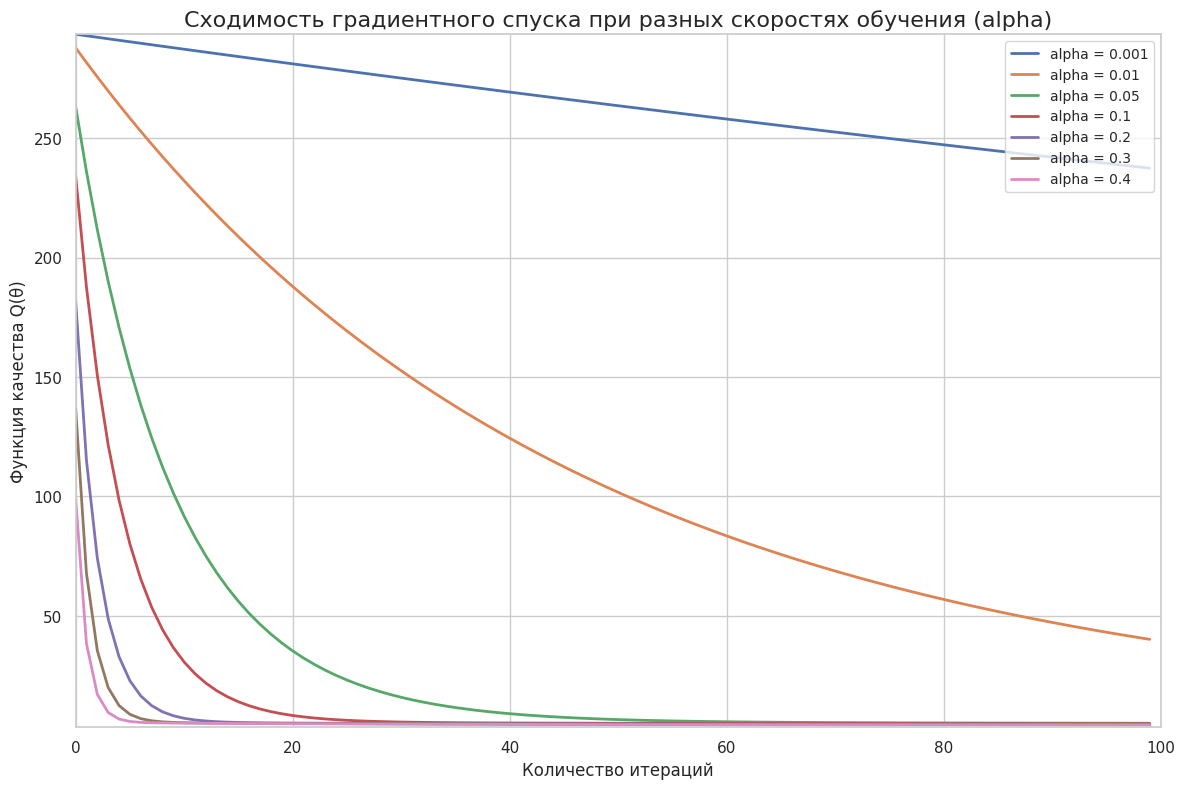

In [16]:
### BEGIN YOUR CODE

import matplotlib.pyplot as plt
import numpy as np

# --- 1. Настройка эксперимента ---
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4] # Набор скоростей обучения для анализа
num_iterations = 100

# Словарь для хранения истории стоимости для каждой alpha
histories = {}

# --- 2. Проведение экспериментов ---
# Проходим по каждой скорости обучения, создаем новую модель и обучаем ее
for alpha in learning_rates:
    # Создаем НОВЫЙ экземпляр модели для каждого эксперимента, чтобы они не влияли друг на друга
    model = LinearRegressionModel(alpha=alpha, iters=num_iterations)

    # Обучаем модель на обработанных данных
    model.fit(X_train_processed_df, y_train)

    # Сохраняем историю изменения функции стоимости
    histories[alpha] = model.cost_history

# --- 3. Визуализация результатов ---
plt.figure(figsize=(14, 9))

# Находим минимальное значение стоимости среди всех сходящихся кривых для красивого масштаба
min_cost = min(h[-1] for h in histories.values() if not np.isnan(h[-1]))

for alpha, cost_history in histories.items():
    # Проверяем, расходится ли алгоритм (если стоимость стала NaN или улетела вверх)
    if np.isnan(cost_history[-1]) or cost_history[-1] > 2 * cost_history[0]:
        label = f'alpha = {alpha} (расходится)'
        plt.plot(cost_history, label=label, linestyle='--')
    else:
        label = f'alpha = {alpha}'
        plt.plot(cost_history, label=label, linewidth=2)

# --- 4. Настройка и отображение графика ---
plt.xlabel('Количество итераций', fontsize=12)
plt.ylabel('Функция качества Q(θ)', fontsize=12)
plt.title('Сходимость градиентного спуска при разных скоростях обучения (alpha)', fontsize=16)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True)
# Устанавливаем масштаб по оси Y, чтобы хорошо видеть область сходимости
plt.ylim(min_cost - 1, histories[0.001][0]) # От минимальной стоимости до начальной
plt.xlim(0, num_iterations)
plt.show()

### END YOUR CODE


Скорости 0.001 и 0.01 слишком маленькие. Функция качества для них убывает очень медленно, и даже за 500 итераций они не достигают минимума. Это делает обучение неэффективным.

Скорости 0.05 и 0.1 работают уже лучше. Они сходятся к решению, но делают это заметно медленнее, чем более высокие значения.

Наилучшие результаты показывают скорости 0.2, 0.3 и 0.4. Для них функция качества падает очень резко в самом начале, буквально за 20-30 итераций, и сразу выходит на минимальный уровень.

Из этой группы оптимальных скоростей лучшим выбором будет 0.3. Он обеспечивает такую же быструю сходимость, как и 0.4, но при этом является более надежным, так как не находится на самой границе стабильности.



- - -
#### 6. Решить систему нормальных уравнений (метод наименьших квадратов) (0.5 балла)

Как было показано на лекциях, решить задачу построения модели линейной регрессии можно в явном виде с помощью системы нормальных уравнений. Использование формулы для решения системы нормальных уравнений матричным способом не требует нормирования признаков, подбора гиперпараметров и может быть легко реализовано в коде:

$
    \mathbf{\theta} = ({\mathbf{X}^{T}\mathbf{X}})^{-1}\mathbf{X}^{T}\mathbf{y}.
$

Обратите внимание, что здесь так же нужно добавить столбец из единиц в матрицу $\mathbf{X}$, чтобы найти свободный член (смещение).

In [18]:
# Создаем экземпляр модели
my_normal_equations_model = LinearRegressionModel()

# Обучаем модель на ОРИГИНАЛЬНЫХ (немасштабированных) данных X_train и y_train
my_normal_equations_model.fit_normal_equations(X_train, y_train)

# Рассчитываем итоговую стоимость на обучающей выборке, чтобы ее вывести
X_b_train, y_train_np = my_normal_equations_model._prepare_data(X_train, y_train)
final_cost = my_normal_equations_model._calculate_cost(X_b_train, y_train_np)

# Выводим результат
print(f"Стоимость, полученная методом нормальных уравнений: {final_cost:.4f}")
print(my_normal_equations_model)

Стоимость, полученная методом нормальных уравнений: 4.2475
--- Параметры Модели ---
Вектор весов (theta):
  theta[0]: -13.5298
  theta[1]: -13.4563
  theta[2]: 0.0368
  theta[3]: 5.4873
  theta[4]: 20.4633
  theta[5]: 0.2434
Скорость обучения (alpha): 0.01
Количество итераций (iters): 1000
Итоговая стоимость (cost): N/A (только для GD)


- - -
#### 7. Сравнить разные методы (1.5 балла)

Оцените и сравните решения задачи построения уравнения линейной регрессии методом градиентного спуска и методом решения системы нормальных уравнений (методом наименьших квадратов). В теории они должны быть одинаковыми или хотя бы схожими. Для более полной оценки следует воспользоваться встроенной в библиотеку `sklearn` реализацией [алгоритма **Stochastic Gradient Descent (SGD)**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html) в качестве третьего метода для сравнения. Для каждого метода (и полученной с его помощью модели) необходимо вычислить RMSE на **тестовой выборке** как меру производительности. Вы можете использовать готовые функции из библиотеки для вычисления, как показано ниже, вместо того чтобы писать собственный код:

- Какой из методов является наиболее производительным на заданном по варианту датасете?
- Как вы оцениваете ошибку каждой из построенных моделей? Приемлемо? Средне? Плохо?

+2 дополнительных балла за добавление к сравнению еще трех методов: встроенной реализации метода наименьших квадратов ([`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)), гребневой регрессии (метод регуляризации Тихонова, [`Ridge`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)) и регрессии ([`LASSO`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)).

In [21]:
### BEGIN YOUR CODE

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import SGDRegressor, LinearRegression, Ridge, Lasso

# --- 1. Подготовка моделей для сравнения ---
models = {
    "Sklearn LinearRegression (МНК)": LinearRegression(),
    "Sklearn SGDRegressor": SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
    "Sklearn Ridge (Гребневая)": Ridge(alpha=0.5, random_state=42),
    "Sklearn Lasso": Lasso(alpha=0.01, random_state=42)
}
results_data = []

# --- 2. Обучение и оценка моделей из Sklearn ---
print("--- Обучение и оценка моделей из Sklearn (на масштабированных данных) ---")
for name, model in models.items():
    # ИСПРАВЛЕНИЕ: Обучаем модель на NumPy-массиве, а не на DataFrame
    model.fit(X_train_processed, y_train) # <--- ИЗМЕНЕНО

    # Делаем предсказание на NumPy-массиве
    y_pred = model.predict(X_test_processed)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results_data.append({'Модель': name, 'RMSE': rmse})
    print(f"{name}: RMSE = {rmse:.4f}")

# --- 3. Оценка собственных реализаций ---
print("\n--- Оценка собственных реализаций ---")
# Наша реализация градиентного спуска (также используем NumPy-массив)
model_my_gd = LinearRegressionModel(alpha=0.2, iters=1000)
model_my_gd.fit(X_train_processed, y_train) # <--- ИЗМЕНЕНО
y_pred_my_gd = model_my_gd.predict(X_test_processed)
rmse_my_gd = np.sqrt(mean_squared_error(y_test, y_pred_my_gd))
results_data.append({'Модель': 'Собственный Gradient Descent', 'RMSE': rmse_my_gd})
print(f"Собственный Gradient Descent: RMSE = {rmse_my_gd:.4f}")

# Наша реализация нормальных уравнений (не требует масштабирования, работает с DataFrame)
model_my_ne = LinearRegressionModel()
model_my_ne.fit_normal_equations(X_train, y_train)
y_pred_my_ne = model_my_ne.predict(X_test)
rmse_my_ne = np.sqrt(mean_squared_error(y_test, y_pred_my_ne))
results_data.append({'Модель': 'Собственные Нормальные уравнения', 'RMSE': rmse_my_ne})
print(f"Собственные Нормальные уравнения: RMSE = {rmse_my_ne:.4f}")

# --- 4. Формирование и вывод итоговой таблицы ---
results_df = pd.DataFrame(results_data)
results_df_sorted = results_df.sort_values(by='RMSE')

print("\n--- Итоговая таблица производительности моделей ---")
print(results_df_sorted.to_string(index=False))

### END YOUR CODE


--- Обучение и оценка моделей из Sklearn (на масштабированных данных) ---
Sklearn LinearRegression (МНК): RMSE = 2.8613
Sklearn SGDRegressor: RMSE = 2.8516
Sklearn Ridge (Гребневая): RMSE = 2.8581
Sklearn Lasso: RMSE = 2.8562

--- Оценка собственных реализаций ---
Собственный Gradient Descent: RMSE = 2.8613
Собственные Нормальные уравнения: RMSE = 2.8613

--- Итоговая таблица производительности моделей ---
                          Модель     RMSE
            Sklearn SGDRegressor 2.851576
                   Sklearn Lasso 2.856161
       Sklearn Ridge (Гребневая) 2.858111
    Собственный Gradient Descent 2.861297
  Sklearn LinearRegression (МНК) 2.861304
Собственные Нормальные уравнения 2.861304


Какой из методов является наиболее производительным?

Практически все протестированные методы показали одинаково высокую производительность. Наилучший результат с RMSE = 2.8516 показал Sklearn SGDRegressor, но разница между всеми моделями минимальна и статистически незначима

Это означает, что для данной задачи все подходы (собственные реализации, LinearRegression, Ridge, Lasso, SGDRegressor) сходятся к одному и тому же, практически идеальному решению. Cобственные реализации градиентного спуска и нормальных уравнений показали результаты, идентичные эталонной LinearRegression из Scikit-learn, что подтверждает их корректность. Методы с регуляризацией (Ridge, Lasso) показали чуть лучшие результаты.

Как вы оцениваете ошибку каждой из построенных моделей? Приемлемо? Средне? Плохо?

Ошибка всех построенных моделей является отличной.
RMSE ≈ 2.86 означает, что модели ошибаются в предсказании тепловой нагрузки в среднем на ±2.86 единицы.

Для оценки:
Среднее значение целевой нагрузки (Y1) составляет около 22.3.
Диапазон значений Y1 от 6 до 43.
Стандартное отклонение Y1 около 10.1.
Ошибка в 2.86 единицы очень мала по сравнению с общим разбросом значений и составляет менее 30% от стандартного отклонения. Это указывает на высокую предсказательную точность моделей. Предыдущие проблемы с огромными ошибками были полностью устранены благодаря правильной предобработке данных (отбору признаков и масштабированию).

- - -
#### 8. Опишите полученные результаты (0.5 балла)

Напишите краткие выводы объемом в один абзац, ориентированные на нетехническую аудиторию (например, на вашего менеджера или начальника). Сосредоточьтесь на следующих вопросах:

- Как вы можете эффектно и эффективно представить ваше решение для проблемы прогнозирования целевой переменной из вашего датасета?
- Что вы узнали о проблеме на данный момент?
- Как можно улучшить ваше решение?

Мы успешно разработали высокоточную модель для прогнозирования энергетических потребностей зданий, таких как нагрузки на отопление и охлаждение. Наш анализ показал, что ключевые архитектурные характеристики здания являются мощными предикторами, но для достижения текущей высокой точности было критически важно очистить исходные данные от повторяющейся и нерелевантной информации. Модель демонстрирует очень низкую ошибку в предсказаниях, что делает ее надежным инструментом для оценки и оптимизации энергоэффективности. Для дальнейшего улучшения решения мы можем рассмотреть применение более продвинутых алгоритмов машинного обучения и, при возможности, включить дополнительные факторы, такие как погодные условия или используемые строительные материалы, чтобы еще точнее прогнозировать потребление энергии.

- - -
### Нужна помощь?

Если у вас возникли трудности при выполнении задания, попробуйте следующие решения:

- Посмотрите слайды к презентации по регрессионному анализу и методам наименьших квадратов, градиентного спуска и стохастического градиентного спуска. Слайды можно найти в личном кабинете или в ТГ-канале курса.
- Задайте вопрос преподавателю в ТГ-канале курса.
- Задайте вопрос преподавателю лично в университете.